In [ ]:
"""
下载 SPY 过去两年日线数据，计算20日动量因子，并用 MAD 去极值（winsorize）。

使用方法：
    pip install -r requirements.txt
    python spy_momentum.py

输出：spy_momentum_2y.csv

文件包含详细中文注释，便于学习与复现。
"""

import yfinance as yf
import pandas as pd
import numpy as np


def download_spy(period: str = "2y") -> pd.DataFrame:
    """下载标普500 ETF SPY 的日线数据。

    参数:
        period: yfinance 可识别的时间区间字符串，例如 '2y'、'1y'、'6mo' 等。
    返回:
        包含 OHLCV 的 pandas DataFrame，索引为日期（Date）。
    """
    # 使用 yfinance 批量下载日线数据
    df = yf.download("SPY", period=period, interval="1d", progress=False)

    # 确保包含我们需要的列
    if "Close" not in df.columns:
        raise RuntimeError("下载的数据不包含 Close 列，请检查 yfinance 返回值。")

    # 将索引转换为日期（如果尚未）并返回
    df.index = pd.to_datetime(df.index)
    return df


def momentum_20(df: pd.DataFrame, price_col: str = "Close") -> pd.Series:
    """计算 20 日动量因子：今天的收盘价 / 20 天前收盘价 - 1。

    参数:
        df: 包含价格数据的 DataFrame。
        price_col: 用于计算的价格列名，默认为 'Close'.
    返回:
        pandas Series，索引与输入 DataFrame 一致，值为动量因子。
    """
    # 使用 shift(20) 获取 20 天前的收盘价
    close = df[price_col]
    mom = close / close.shift(20) - 1.0
    mom.name = "momentum_20"
    return mom

def mad_winsorize(series: pd.Series, n: float = 3.0) -> pd.Series:
    """基于中位数绝对偏差(MAD)的去极值（winsorize）函数。

    说明：
    - 先计算序列的中位数 m = median(x)
    - 计算 MAD = median(|x - m|)
    - 将值限制到 [m - n * MAD, m + n * MAD] 区间内
    - 若 MAD 为 0（序列非常平坦），退回到基于分位数的去极值处理（1%/99%）

    参数:
        series: 待处理的一维数据（pandas Series）
        n: MAD 的倍数阈值，常用取值 2~3
    返回:
        处理后的 pandas Series（与输入索引对齐）
    """
    # 拷贝输入，避免原地修改
    s = series.copy()

    # 计算中位数与 MAD
    median = s.median()
    mad = np.median(np.abs(s.dropna() - median))

    # 当 mad 非零时按 MAD 界限截断（winsorize）
    if mad > 0:
        lower = median - n * mad
        upper = median + n * mad
        # 使用 clip 将超出范围的值限制在边界上
        s = s.clip(lower=lower, upper=upper)
    else:
        # 当 MAD 为 0 时，数据可能是常数或接近常数，使用百分位数退避
        lower = s.quantile(0.01)
        upper = s.quantile(0.99)
        s = s.clip(lower=lower, upper=upper)

    return s


def main():
    # 下载过去两年的日线数据
    df = download_spy("2y")

    # 计算 20 日动量因子
    df["momentum_20"] = momentum_20(df, price_col="Close")

    # 对动量因子进行 MAD 去极值处理（默认 n=3）
    df["momentum_20_mad_winsor"] = mad_winsorize(df["momentum_20"], n=3.0)

    # 保存结果到 CSV，包含日期索引
    out_file = "spy_momentum_2y.csv"
    df.to_csv(out_file, index=True, float_format="%.6f")

    print(f"已保存结果到 {out_file}，包含原始动量和 MAD 去极值后的动量列。")


if __name__ == "__main__":
    main()


In [ ]:
import pandas as pd

# 读取 AI 刚才帮你算好并保存的那个数据文件
data = pd.read_csv('spy_momentum_2y.csv')

# 召唤数据表格（tail()表示只看最后5天）
data.tail()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------- 1. 设定交易信号 (Trading Signal) -----------------
# 极简量化逻辑：当 20日动量 > 0 时全仓买入/持有 (信号为 1)，否则空仓持币 (信号为 0)
data['Signal'] = np.where(data['momentum_20'] > 0, 1, 0)

# 🚨 量化面试高频考点【避免未来函数/前视偏差】：
# 我们今天收盘才能算出今天的动量，所以我们只能在“明天”执行买入，信号必须向后平移1天 (shift(1))
data['Position'] = data['Signal'].shift(1)

# ----------------- 2. 计算收益率 -----------------
# 计算大盘基准（标普500）每天的涨跌幅
data['Market_Return'] = data['Close'].pct_change()

# 计算我们策略每天的收益率 = 昨天的仓位 * 今天的涨跌幅
data['Strategy_Return'] = data['Position'] * data['Market_Return']

# ----------------- 3. 计算累计资金净值 -----------------
# 假设初始资金为 1，计算复利累计净值
data['Cumulative_Market'] = (1 + data['Market_Return']).cumprod()
data['Cumulative_Strategy'] = (1 + data['Strategy_Return']).cumprod()

# ----------------- 4. 计算三大核心量化绩效指标 -----------------
# 1. 年化收益率 (以美股每年252个交易日计算)
total_days = len(data)
strategy_annual_return = (data['Cumulative_Strategy'].iloc[-1]) ** (252 / total_days) - 1

# 2. 夏普比率 (Sharpe Ratio, 假设无风险利率为 2%)
risk_free_rate = 0.02
daily_rf = (1 + risk_free_rate) ** (1/252) - 1
excess_return = data['Strategy_Return'] - daily_rf
sharpe_ratio = np.sqrt(252) * (excess_return.mean() / data['Strategy_Return'].std())

# 3. 最大回撤 (Max Drawdown, 衡量最大亏损幅度)
rolling_max = data['Cumulative_Strategy'].cummax()
drawdown = (data['Cumulative_Strategy'] - rolling_max) / rolling_max
max_drawdown = drawdown.min()

print("=" * 30)
print(f"📊 策略年化收益率: {strategy_annual_return * 100:.2f}%")
print(f"📈 策略夏普比率:   {sharpe_ratio:.2f}")
print(f"📉 策略最大回撤:   {max_drawdown * 100:.2f}%")
print("=" * 30)

# ----------------- 5. 绘制策略收益对比曲线 -----------------
plt.figure(figsize=(12, 6))
plt.plot(data['Cumulative_Market'], label='Benchmark (SPY Buy & Hold)', color='gray', alpha=0.7, linestyle='--')
plt.plot(data['Cumulative_Strategy'], label='Momentum Strategy (Our Model)', color='red', linewidth=2)
plt.title('Momentum Strategy vs Benchmark (SPY) Backtest', fontsize=14)
plt.xlabel('Date / Steps', fontsize=12)
plt.ylabel('Cumulative Return (Base = 1.0)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

1. 正在直接获取最新数据，绕过本地 CSV...
2. 正在计算 20日动量因子并进行去极值处理...
3. 正在执行量化回测与资金流转计算...

📊 策略年化收益率: 13.34%
📈 策略夏普比率:   1.14
📉 策略最大回撤:   -7.43%
4. 正在生成收益率对比图...


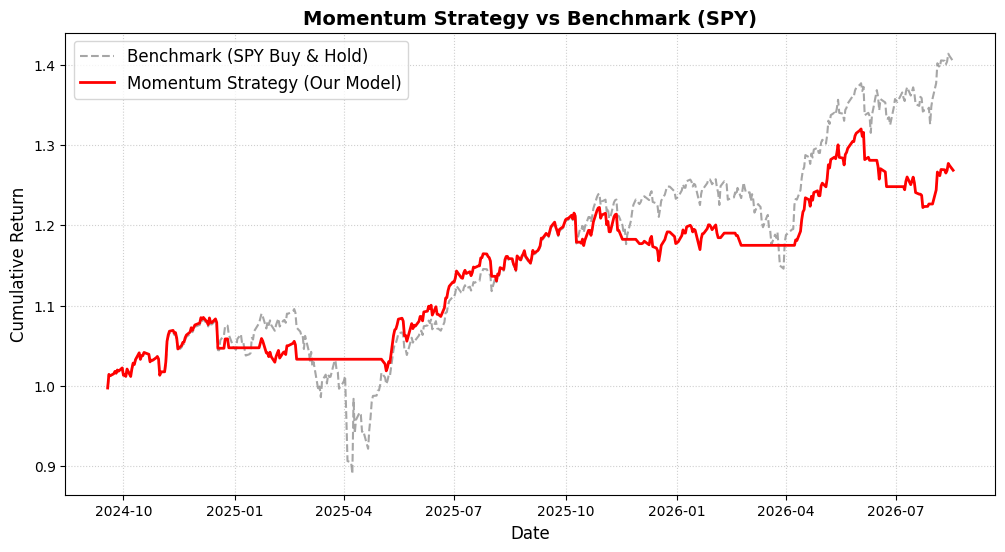

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("1. 正在直接获取最新数据，绕过本地 CSV...")
data = yf.download("SPY", period="2y", interval="1d", progress=False)

# 🚨 核心排雷：修复 yfinance 新版的双层表头问题
if isinstance(data.columns, pd.MultiIndex):
    data.columns = [col[0] for col in data.columns] # 强行把双层表头拍扁成单层

# 强制转换为纯数字
data['Close'] = pd.to_numeric(data['Close'], errors='coerce')

print("2. 正在计算 20日动量因子并进行去极值处理...")
data['momentum_20'] = data['Close'] / data['Close'].shift(20) - 1

def mad_filter(series, n=3):
    median = series.median()
    mad = (series - median).abs().median()
    upper_bound = median + n * mad * 1.4826
    lower_bound = median - n * mad * 1.4826
    return series.clip(lower=lower_bound, upper=upper_bound)

data['momentum_20'] = mad_filter(data['momentum_20'])
data = data.dropna().copy()

print("3. 正在执行量化回测与资金流转计算...")
data['Signal'] = np.where(data['momentum_20'] > 0, 1, 0)
data['Position'] = data['Signal'].shift(1) # T+1 交易防偷看

data['Market_Return'] = data['Close'].pct_change()
data['Strategy_Return'] = data['Position'] * data['Market_Return']
data = data.dropna().copy()

# 计算累计资金净值
data['Cumulative_Market'] = (1 + data['Market_Return']).cumprod()
data['Cumulative_Strategy'] = (1 + data['Strategy_Return']).cumprod()

# 计算三大核心指标
total_days = len(data)
strategy_annual_return = (data['Cumulative_Strategy'].iloc[-1]) ** (252 / total_days) - 1

risk_free_rate = 0.02
daily_rf = (1 + risk_free_rate) ** (1/252) - 1
excess_return = data['Strategy_Return'] - daily_rf
sharpe_ratio = np.sqrt(252) * (excess_return.mean() / data['Strategy_Return'].std())

rolling_max = data['Cumulative_Strategy'].cummax()
max_drawdown = ((data['Cumulative_Strategy'] - rolling_max) / rolling_max).min()

print("\n" + "=" * 40)
print(f"📊 策略年化收益率: {strategy_annual_return * 100:.2f}%")
print(f"📈 策略夏普比率:   {sharpe_ratio:.2f}")
print(f"📉 策略最大回撤:   {max_drawdown * 100:.2f}%")
print("=" * 40)

print("4. 正在生成收益率对比图...")
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Cumulative_Market'], label='Benchmark (SPY Buy & Hold)', color='gray', alpha=0.7, linestyle='--')
plt.plot(data.index, data['Cumulative_Strategy'], label='Momentum Strategy (Our Model)', color='red', linewidth=2)
plt.title('Momentum Strategy vs Benchmark (SPY)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()